In [4]:
pip install opencv-python scikit-image xgboost scikit-learn tqdm

You should consider upgrading via the 'c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [5]:
import zipfile
import os

# =========================
# PATH CONFIGURATION
# =========================

ZIP_PATH = r"archive.zip"   # ← your zip file
EXTRACT_PATH = r"dataset"             # ← dataset folder (updated for Colab environment)

# =========================
# STEP 1: EXTRACT ZIP FILE
# =========================

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset extracted successfully")

# =========================
# DEBUGGING: LIST CONTENTS OF EXTRACTED PATH
# =========================
print("📂 Contents of extracted path:")
for item in os.listdir(EXTRACT_PATH):
    print(f" - {item}")

# =========================
# STEP 2: SET TRAIN FOLDER
# =========================

# Correcting TRAIN_DIR path to account for the nested 'Dataset' folder
TRAIN_DIR = os.path.join(EXTRACT_PATH, "Dataset", "train")

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError("❌ Train folder not found inside dataset")

print("✅ Train folder found:", TRAIN_DIR)

# =========================
# STEP 3: VERIFY CLASSES
# =========================

classes = [d for d in os.listdir(TRAIN_DIR)
           if os.path.isdir(os.path.join(TRAIN_DIR, d))]

print("📂 Classes detected:")
for cls in classes:
    print(" -", cls)

✅ Dataset extracted successfully
📂 Contents of extracted path:
 - Dataset
✅ Train folder found: dataset\Dataset\train
📂 Classes detected:
 - Bacterial Leaf Blight
 - Brownspot
 - Leafsmut


In [6]:
import cv2
import numpy as np
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.stats import skew

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
def preprocess_image(img_path, size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.resize(img, size)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    return img


In [8]:
def extract_glcm_features(gray):
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0]
    ]


In [9]:
def extract_lbp_features(gray):
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10),
        density=True
    )
    return hist.tolist()


In [10]:
def extract_lbp_features(gray):
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10),
        density=True
    )
    return hist.tolist()


In [11]:
def extract_color_features(img):
    # Convert image to HSV color space for better color separation
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Calculate mean and standard deviation for each channel
    h_mean, h_std = hsv[:,:,0].mean(), hsv[:,:,0].std()
    s_mean, s_std = hsv[:,:,1].mean(), hsv[:,:,1].std()
    v_mean, v_std = hsv[:,:,2].mean(), hsv[:,:,2].std()

    # Calculate skewness for each channel
    h_skew = skew(hsv[:,:,0].flatten())
    s_skew = skew(hsv[:,:,1].flatten())
    v_skew = skew(hsv[:,:,2].flatten())

    return [h_mean, h_std, h_skew, s_mean, s_std, s_skew, v_mean, v_std, v_skew]

X = []
y = []

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in tqdm(os.listdir(class_path), desc=class_name):
        img_path = os.path.join(class_path, img_name)

        img = preprocess_image(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features = []
        features.extend(extract_glcm_features(gray))
        features.extend(extract_lbp_features(gray))
        features.extend(extract_color_features(img))

        X.append(features)
        y.append(class_name)


Leafsmut: 100%|██████████| 180/180 [00:01<00:00, 112.06it/s]


In [12]:
X = np.array(X)
y = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)


Classes: ['Bacterial Leaf Blight' 'Brownspot' 'Leafsmut']


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.28,   # ↑ from 0.30
    random_state=42,
    stratify=y_encoded
)


In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import numpy as np

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []

for i, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded)):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]

    model = XGBClassifier(
        objective="multi:softmax",   # ✅ Correct for direct class prediction
        num_class=len(label_encoder.classes_),
        n_estimators=450,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.80,
        min_child_weight=5,
        gamma=0.15,                  # prevents overfitting
        reg_alpha=0.9,
        reg_lambda=1.5,
        eval_metric="mlogloss",
        random_state=42,
        use_label_encoder=False
    )

    model.fit(X_tr, y_tr)

    # Predict class labels
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    acc_scores.append(acc)

    print(f"Fold {i+1} Accuracy: {acc:.4f}")

print("\n✅ Cross-Validated Accuracy:", np.mean(acc_scores))


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1 Accuracy: 0.9444


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 2 Accuracy: 0.9815
Fold 3 Accuracy: 0.9907


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 4 Accuracy: 0.9444


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 5 Accuracy: 0.9630

✅ Cross-Validated Accuracy: 0.9648148148148149


In [16]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,

    target_names=label_encoder.classes_
))

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:23:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9605263157894737
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.92      0.98      0.95        50
            Brownspot       0.96      1.00      0.98        51
             Leafsmut       1.00      0.90      0.95        51

             accuracy                           0.96       152
            macro avg       0.96      0.96      0.96       152
         weighted avg       0.96      0.96      0.96       152



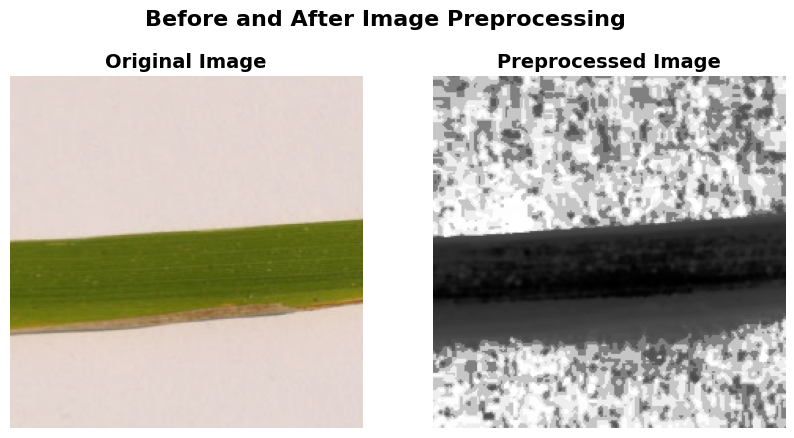

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def preprocess_image(img):
    img = cv2.resize(img, (224, 224))
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    img_norm = cv2.normalize(img_blur, None, 0, 255, cv2.NORM_MINMAX)
    gray = cv2.cvtColor(img_norm, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    return equalized

# Sample image
sample_class = os.listdir(TRAIN_DIR)[0]
sample_img_path = os.path.join(TRAIN_DIR, sample_class,
                               os.listdir(os.path.join(TRAIN_DIR, sample_class))[0])

original = cv2.imread(sample_img_path)
processed = preprocess_image(original)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image", fontsize=14, fontweight="bold")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Preprocessed Image", fontsize=14, fontweight="bold")
plt.axis("off")

plt.suptitle("Before and After Image Preprocessing",
             fontsize=16, fontweight="bold")
plt.show()



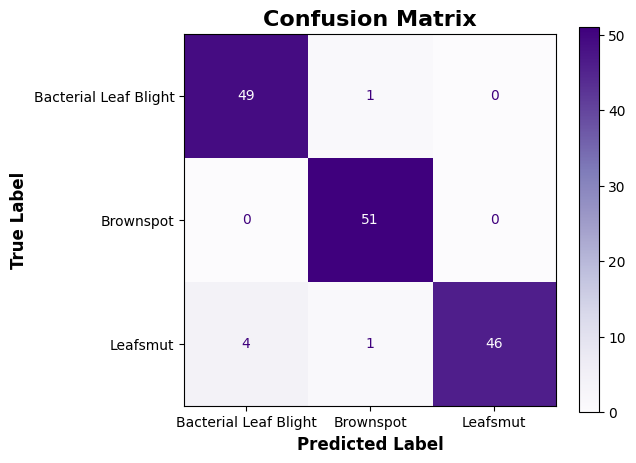

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Purples", values_format="d")

ax.set_title("Confusion Matrix",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Predicted Label",
              fontsize=12, fontweight="bold")
ax.set_ylabel("True Label",
              fontsize=12, fontweight="bold")

plt.show()


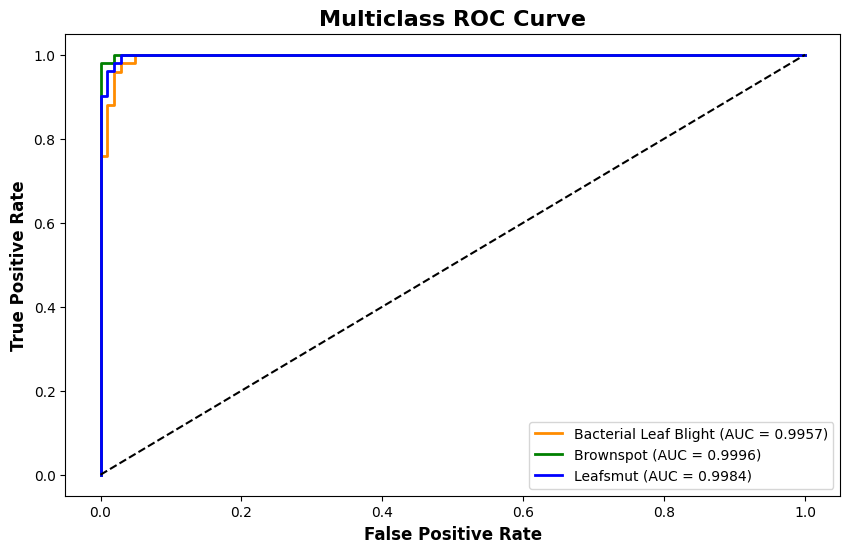

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_prob = model.predict_proba(X_test)

plt.figure(figsize=(10,6))
colors = ["darkorange", "green", "blue"]

for i, cls in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr,
             color=colors[i],
             linewidth=2,
             label=f"{cls} (AUC = {roc_auc:.4f})")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate",
           fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate",
           fontsize=12, fontweight="bold")
plt.title("Multiclass ROC Curve",
          fontsize=16, fontweight="bold")
plt.legend()
plt.grid(False)
plt.show()



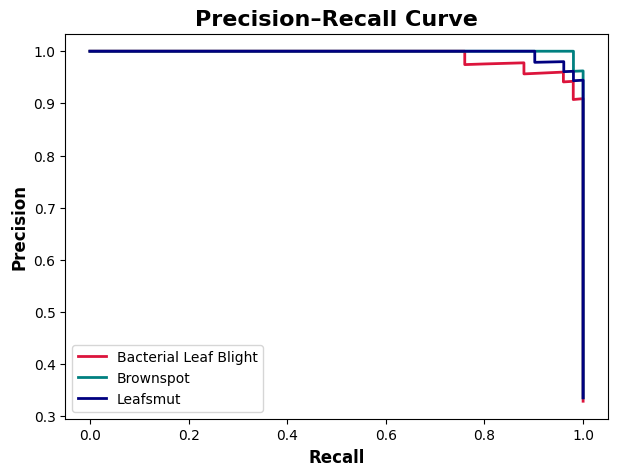

In [20]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,5))
colors = ["crimson", "teal", "navy"]

for i, cls in enumerate(label_encoder.classes_):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision,
             color=colors[i],
             linewidth=2,
             label=cls)

plt.xlabel("Recall",
           fontsize=12, fontweight="bold")
plt.ylabel("Precision",
           fontsize=12, fontweight="bold")
plt.title("Precision–Recall Curve",
          fontsize=16, fontweight="bold")
plt.legend()
plt.grid(False)
plt.show()



In [21]:
plt.figure(figsize=(8,4))
x = np.arange(len(label_encoder.classes_))

bars1 = plt.bar(x - 0.2, FPR, 0.4,
                label="FPR", color="blue")
bars2 = plt.bar(x + 0.2, FNR, 0.4,
                label="FNR", color="purple")

plt.xticks(x, label_encoder.classes_,
           fontsize=11, fontweight="bold")
plt.ylabel("Rate",
           fontsize=12, fontweight="bold")
plt.xlabel("Error",
           fontsize=12, fontweight="bold")
plt.title("FPR & FNR",
          fontsize=16, fontweight="bold")
plt.legend()

# 🔹 Value labels on top
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 0.001,
                 f"{height:.3f}",
                 ha="center",
                 fontsize=10,
                 fontweight="bold")

plt.ylim(0, 0.1)
plt.show()


NameError: name 'FPR' is not defined

<Figure size 800x400 with 0 Axes>

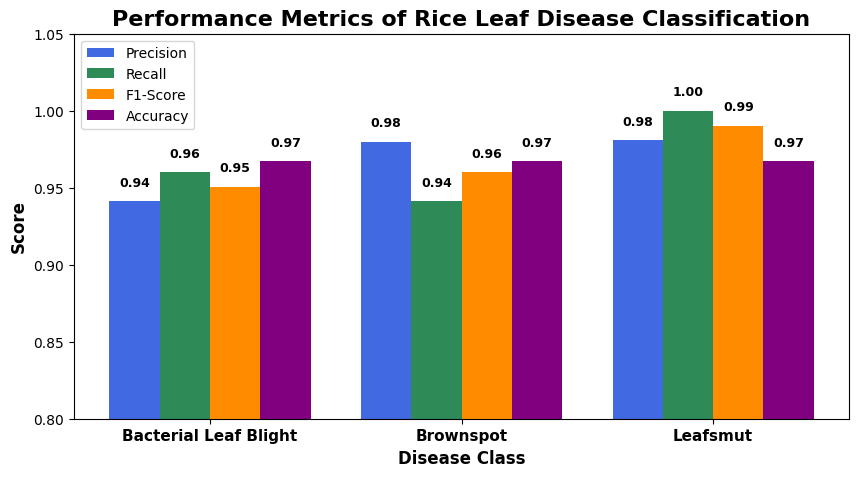

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# Metrics
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
accuracy = accuracy_score(y_test, y_pred)

# Repeat accuracy for plotting
accuracy_vals = [accuracy] * len(label_encoder.classes_)

x = np.arange(len(label_encoder.classes_))
width = 0.2

plt.figure(figsize=(10,5))

bars1 = plt.bar(x - 1.5*width, precision, width,
                label="Precision", color="royalblue")
bars2 = plt.bar(x - 0.5*width, recall, width,
                label="Recall", color="seagreen")
bars3 = plt.bar(x + 0.5*width, f1, width,
                label="F1-Score", color="darkorange")
bars4 = plt.bar(x + 1.5*width, accuracy_vals, width,
                label="Accuracy", color="purple")

plt.xticks(x, label_encoder.classes_,
           fontsize=11, fontweight="bold")
plt.xlabel("Disease Class",
           fontsize=12, fontweight="bold")
plt.ylabel("Score",
           fontsize=12, fontweight="bold")
plt.title("Performance Metrics of Rice Leaf Disease Classification",
          fontsize=16, fontweight="bold")
plt.ylim(0.8, 1.05)
plt.legend()

# Value labels on top
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 h + 0.01,
                 f"{h:.2f}",
                 ha="center",
                 fontsize=9,
                 fontweight="bold")

plt.show()


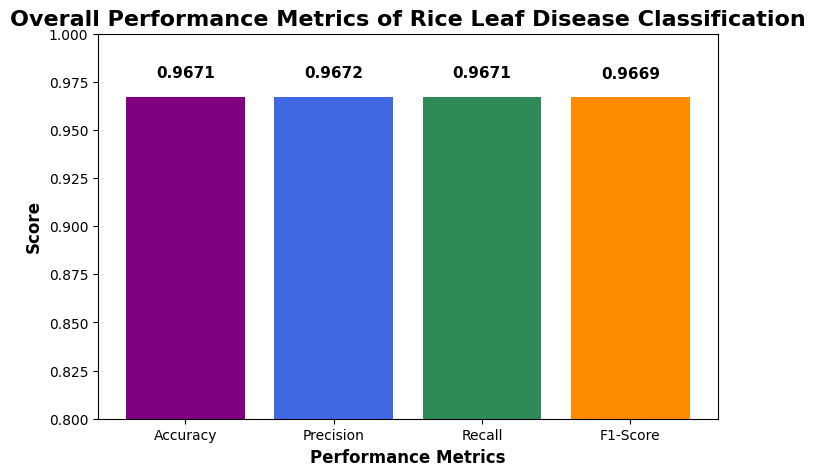

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

# ---- Compute combined metrics ----
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

metrics = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = ["purple", "royalblue", "seagreen", "darkorange"]

# ---- Plot ----
plt.figure(figsize=(8,5))
bars = plt.bar(labels, metrics, color=colors)

plt.xlabel("Performance Metrics", fontsize=12, fontweight="bold")
plt.ylabel("Score", fontsize=12, fontweight="bold")
plt.title("Overall Performance Metrics of Rice Leaf Disease Classification",
          fontsize=16, fontweight="bold")

plt.ylim(0.8, 1.0)

# ---- Value labels on top ----
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.01,
             f"{h:.4f}",
             ha="center",
             fontsize=11,
             fontweight="bold")

plt.show()


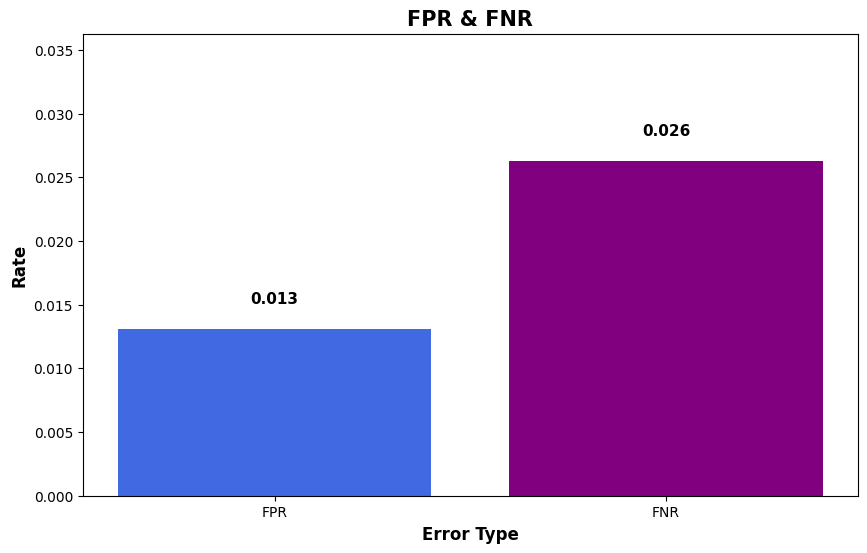

In [ ]:
import matplotlib.pyplot as plt

# Calculate mean FPR and FNR
FPR_mean = np.mean(FPR) # Calculate the mean of the FPR array
FNR_mean = np.mean(FNR) # Calculate the mean of the FNR array

labels = ["FPR", "FNR"]
values = [FPR_mean, FNR_mean]
colors = ["royalblue", "purple"]

plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color=colors)

plt.xlabel("Error Type", fontsize=12, fontweight="bold")
plt.ylabel("Rate", fontsize=12, fontweight="bold")
plt.title("FPR & FNR",
          fontsize=15, fontweight="bold")

plt.ylim(0, max(values) + 0.01)

# 🔹 Value labels
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.002,
             f"{h:.3f}",
             ha="center",
             fontsize=11,
             fontweight="bold")

plt.show()

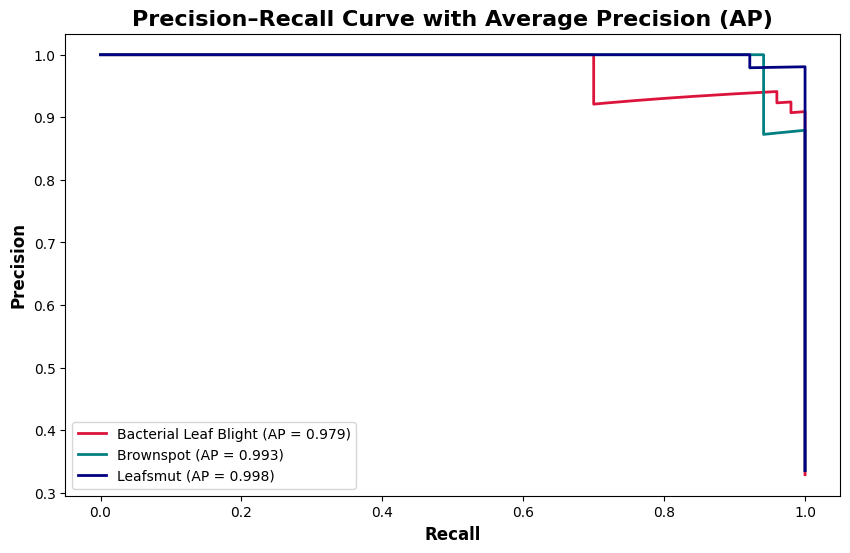

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
colors = ["crimson", "teal", "navy"]

for i, cls in enumerate(label_encoder.classes_):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_prob[:, i]
    )

    # ✅ Average Precision (AP)
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])

    plt.plot(
        recall, precision,
        color=colors[i],
        linewidth=2,
        label=f"{cls} (AP = {ap:.3f})"
    )

plt.xlabel("Recall", fontsize=12, fontweight="bold")
plt.ylabel("Precision", fontsize=12, fontweight="bold")
plt.title("Precision–Recall Curve with Average Precision (AP)",
          fontsize=16, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(False)
plt.show()
